In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [7]:
df.drop(['Car_Name'], axis=1, inplace=True)

In [10]:
print(df.columns)

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

In [12]:
X = df.drop(['Selling_Price'], axis=1)

y = df['Selling_Price']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
predictions = model.predict(X_test)

print(predictions)

[ 2.96562958  8.30085782  6.05782751 -1.46736816  9.25705687  7.03171029
  1.35032876  0.82691573  1.36987479  7.10758777  8.74146173  0.58642748
  8.50459253  3.42661966  6.50292735  3.08732011  0.46492161 10.89305942
  1.76225878  2.36483065  0.37623881  7.73151022  6.20981391  2.65038024
  0.78195056  3.72251099  5.3340761   2.84078903  2.15815992  1.77018609
  0.37934652  8.79022344 -0.69755203  2.30364091  8.21352459  4.54034656
  7.35264949  7.68532992  2.91820641  8.08316508  4.00325157  4.35384555
  4.36428366  0.60942277  6.94443091  0.47315352  7.41534765 11.442946
  3.14938081  4.95296902  6.86419835  2.19604944 20.53785454 16.78959932
  7.13843807  9.82975063  4.49877206  8.61930717  1.81754614  7.67258754
  0.21141592]


In [16]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("Accuracy:", score)

Accuracy: 0.8466902419662664


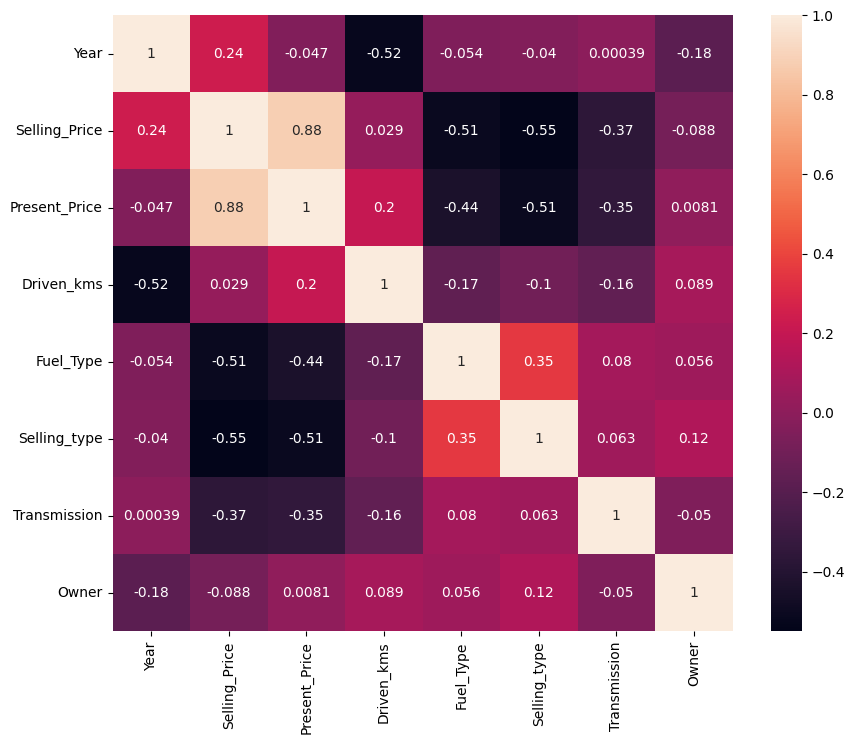

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

RandomForestRegressor()

In [20]:
rf_pred = rf.predict(X_test)

print(rf_pred)

[ 0.4367 10.795   4.8875  0.1979  7.4265  6.6925  1.0845  0.5875  0.4754
  6.8025  8.0073  1.0702  7.6433  0.4484  5.26    2.6775  1.1276 13.8215
  0.4749  1.5625  0.338   8.3245  4.716   2.705   0.5092  3.5255  5.3415
  3.1435  1.1984  1.1667  0.4112  9.5565  0.4638  2.6475  7.7939  4.253
  6.385   6.1249  2.5875  6.6975  4.1137  3.4373  5.023   0.583   6.519
  0.7663  7.884   7.1555  2.852   3.4975  4.9365  1.5075 22.2137 20.086
  6.576  10.2899  5.148   8.8411  2.761   6.755   0.2337]


In [21]:
from sklearn.metrics import r2_score

rf_score = r2_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_score)

Random Forest Accuracy: 0.9608053687321801


In [22]:
print("Linear Regression Accuracy:", score)
print("Random Forest Accuracy:", rf_score)

Linear Regression Accuracy: 0.8466902419662664
Random Forest Accuracy: 0.9608053687321801


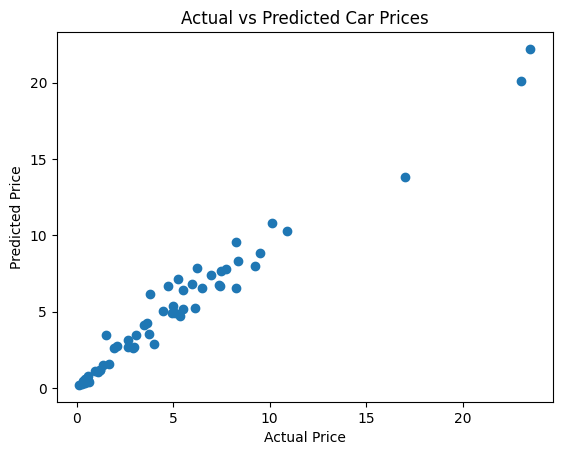

In [23]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()